In [1]:
import cosmosis
import sys, os
%load_ext autoreload
%autoreload 2
# csdir = '/Users/shivam/Library/CloudStorage/Dropbox/research/cosmosis-standard-library/'
csdir = '/Users/shivam/Library/CloudStorage/Dropbox/research/cosmosis-standard-library/'
os.chdir(csdir)
from cosmosis.runtime.config import Inifile
from cosmosis.runtime.pipeline import LikelihoodPipeline
from scipy.stats import norm
from scipy.linalg import sqrtm
from threadpoolctl import threadpool_limits
old_stdout = sys.stdout
sys.stdout = open(os.devnull, 'w')
pipeline = cosmosis.runtime.pipeline.LikelihoodPipeline(cosmosis.runtime.config.Inifile(f"{csdir}/examples/des-y3_3x2pt_code_compare.ini",
                            # override={
                                # ('DEFAULT', '2pt_file'):f"{csdir}/examples/bz_forecast/dv_final/y3nz_lssty10_simulation_wNLA_wmag_wkappaCMB_magfix.fits",
                                # ('pipeline', 'values'):'examples/des-y3-shear-values_codecompare.ini',
                                    # ('save_2pt','filename'):'output/sim_fid_lsstY10_y3nz_with_bz_mz_balv' + str(alv) + '_malv' + str(mlv) + '_wIA_wmag_magfix.fits',
                                # ('save_2pt','copy_covariance'):f"{csdir}/examples/bz_forecast/dv_final/y3nz_lssty10_simulation_wNLA_wmag_wkappaCMB_magfix.fits",        
                            # }
                            ))

start_y3fid = pipeline.start_vector()
results_fid_cs = pipeline.run_results(start_y3fid)







Setting up module consistency
------------------------------

Setting up module bbn_consistency
----------------------------------

Setting up module camb
-----------------------

Setting up module extrapolate
------------------------------

Setting up module fast_pt
--------------------------

Setting up module fits_nz
--------------------------

Setting up module lens_photoz_width
------------------------------------

Setting up module lens_photoz_bias
-----------------------------------

Setting up module source_photoz_bias
-------------------------------------

Setting up module IA
---------------------

Setting up module pk_to_cl_gg
------------------------------

Setting up module pk_to_cl
---------------------------

Setting up module add_intrinsic
--------------------------------

Setting up module 2pt_shear
----------------------------

Setting up module 2pt_gal
--------------------------

Setting up module 2pt_gal_shear
--------------------------------

Setting up module she

/Users/shivam/Library/CloudStorage/Dropbox/research/cosmosis-standard-library/structure/projection/projection_tools/kernel.py:35: UserWarning: Some of your n(z) or other kernels are negative.
  warnings.warn("Some of your n(z) or other kernels are negative.")


Using likelihooods from first run:
 - 2pt
 - shear_ratio


/Users/shivam/Library/CloudStorage/Dropbox/research/cosmosis-standard-library/shear/cl_to_xi_fullsky/cl_to_xi.py:36: RuntimeWarning: divide by zero encountered in log
  spec = np.exp(self.interp_func(np.log(angle)))


In [2]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
# platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
# jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')

import matplotlib
os.chdir('/Users/shivam/Library/CloudStorage/Dropbox/research/GODMAX/notebooks')
import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
%load_ext autoreload
%autoreload 2
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../data/") 
abs_path_src = os.path.abspath(curr_path / "../src/") 
abs_path_results = os.path.abspath(curr_path / "../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

%matplotlib inline
%load_ext autoreload
%autoreload 2




/Users/shivam/micromamba/envs/jax-metal/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [68]:
from deepmerge import always_merger
import yaml
abs_path_params = os.path.abspath(curr_path / "../param_files/")

def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
new_data = read_yaml(abs_path_params + '/DESxACT/params_v2.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)

from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 4
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])

analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]

lmin, lmax, dl_log_array = 1.0, 81000.0, 0.23025851/3.
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)
analysis_dict['tSZ_transition_model'] = 'poweradd'
analysis_dict['model_matter'] = 'halofit'


other_params_dict['A_IA'] = 0.0
other_params_dict['eta_IA'] = 0.0
H0 = results_fid_cs.block['cosmological_parameters', 'h0'] * 100
Om = results_fid_cs.block['cosmological_parameters', 'omega_m']
Ob = results_fid_cs.block['cosmological_parameters', 'omega_b']
sigma8 = results_fid_cs.block['cosmological_parameters', 'sigma_8']
ns = results_fid_cs.block['cosmological_parameters', 'n_s']

cosmo_params_dict = {'flat': True, 'H0': H0, 'Om0': Om, 'Ob0': Ob, 'sigma8': sigma8, 'ns': ns, 'w0':-1.0}
sim_params_dict['cosmo'] = cosmo_params_dict



In [69]:
halo_params_dict['nz'] = 32
halo_params_dict['zmax'] = 2.0

halo_params_dict['nz_for_Cls'] = 96
halo_params_dict['zmax'] = 2.0




In [70]:
from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi

# get_power_test = get_power_BCMP(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
xis_test = get_xi(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)




In [71]:
probe = 'xip_xim'
# deproj = 'cib_1p7'
true_y_file = 'ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy'  


save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v2/')
# df_measure = pk.load(open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/DESxACT_gty_xip_xim_DV_ilc_SZ_yy.pk', 'rb'))
df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{true_y_file}.pk', 'rb'))
cov_total = df_measure['cov_total']
xi_all = df_measure['xi_all']
theta_all = df_measure['theta_all']
cov_total = jnp.array(cov_total)
data_vec = jnp.array(xi_all)

gty_dv = data_vec[:80]
sig_gty_dv = np.sqrt(np.diag(cov_total))[:80]
df_cs = fits.open(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits') 

xip_dv = data_vec[80:280]
sig_xip_dv = np.sqrt(np.diag(cov_total))[80:280]
bin1_xip_dv = df_cs['xip'].data['BIN1']
bin2_xip_dv = df_cs['xip'].data['BIN2']

xim_dv = data_vec[280:]
sig_xim_dv = np.sqrt(np.diag(cov_total))[280:]
bin1_xim_dv = df_cs['xim'].data['BIN1']
bin2_xim_dv = df_cs['xim'].data['BIN2']





In [72]:
import configobj
probe = 'xip_xim'

if probe == 'xip_xim':
    cov_total = cov_total[80:, 80:]
    data_vec = data_vec[80:]
elif probe == 'gty':
    cov_total = cov_total[:80, :80]
    data_vec = data_vec[:80]

fname = abs_path_data + '/DESxACT/scale_cuts_xipm_y3_gty_fid.ini'
config = configobj.ConfigObj(fname)
sc_xipm = config['shear-shear']
sc_gty = config['shear-tsz']

df_cs = fits.open(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits') 
bin1_vals =  df_cs['xip'].data['BIN1'][::20]
bin2_vals =  df_cs['xip'].data['BIN2'][::20]
biny_vals = np.array([1,2,3,4])
ang_vals = df_cs['xip'].data['ANG'][0:20]

def process_indices(num, bin1_vals, bin2_vals, angle_ranges, offset, probe, angle_type, do_scalecuts):
    indices, indrm = [], []
    for js in range(num):
        binv, thetav = divmod(js, 20)
        bin1, bin2 = (bin1_vals[binv] - 1, bin2_vals[binv] - 1) if angle_type != 'gty' else (None, None)
        if do_scalecuts:
            sc_min, sc_max = map(float, angle_ranges[binv].split())
        else:
            sc_min, sc_max = 1e-3, 999.0
        if sc_min < ang_vals[thetav] < sc_max:
            indices.append([int(thetav), int(bin1), int(bin2)] if bin1 is not None else [int(thetav), int(binv)])
        elif probe in [angle_type, 'all']:
            indrm.append(int(offset + js))
    return jnp.array(indices, dtype=jnp.int32), jnp.array(indrm, dtype=jnp.int32)

# Process gty indices
sc_ranges_gty = [sc_gty[f'angle_range_gty_{biny}_0'] for biny in biny_vals]
index_gty, indrm_gty = process_indices(80, None, None, sc_ranges_gty, 0, probe, 'gty', True)
len_ind_gty = len(index_gty)
# Process xip indices
sc_ranges_xip = [sc_xipm[f'angle_range_xip_{bin1}_{bin2}'] for bin1, bin2 in zip(bin1_vals, bin2_vals)]
offset_xip = 80 if probe in ['gty', 'all'] else 0
index_xip, indrm_xip = process_indices(200, bin1_vals, bin2_vals, sc_ranges_xip, offset_xip, probe, 'xip_xim', True)
len_ind_xip = len(index_xip)
# Process xim indices
sc_ranges_xim = [sc_xipm[f'angle_range_xim_{bin1}_{bin2}'] for bin1, bin2 in zip(bin1_vals, bin2_vals)]
offset_xim = 280 if probe in ['gty', 'all'] else 200
index_xim, indrm_xim = process_indices(200, bin1_vals, bin2_vals, sc_ranges_xim, offset_xim, probe, 'xip_xim', True)
len_ind_xim = len(index_xim)

indrm = jnp.concatenate([indrm_gty, indrm_xip, indrm_xim], dtype=jnp.int32)
print('removing indices: ', indrm)

if len(indrm) > 0:
    data_vec = jnp.delete(data_vec, indrm)
    cov_total = jnp.delete(cov_total, indrm, axis=0)
    cov_total = jnp.delete(cov_total, indrm, axis=1)
P_total = jnp.linalg.inv(cov_total)


def get_gty_from_index(index):
    index_val = index_gty[index]
    return xis_test.gty_out_mat[index_val[0], index_val[1]]

def get_xip_from_index(index):
    index_val = index_xip[index]
    return xis_test.xip_out_mat[index_val[0], index_val[1], index_val[2]]

def get_xim_from_index(index):
    index_val = index_xim[index]
    return xis_test.xim_out_mat[index_val[0], index_val[1], index_val[2]]

gty_val = vmap(get_gty_from_index)(jnp.arange(len_ind_gty))
xip_val = vmap(get_xip_from_index)(jnp.arange(len_ind_xip))
xim_val = vmap(get_xim_from_index)(jnp.arange(len_ind_xim))

if probe == 'xip_xim':
    mu = jnp.concatenate([xip_val, xim_val])
elif probe == 'gty':
    mu = gty_val
else:
    mu = jnp.concatenate([gty_val, xip_val, xim_val])

# pl.figure()
# pl.plot(mu)
# pl.yscale('log')



In [73]:
diff = mu - data_vec
chi2 = diff.T @ jnp.linalg.inv(cov_total) @ diff


In [74]:
# results_fid_cs.block['data_vector', '2pt_theory'].shape, results_fid_cs.block['data_vector', '2pt_chi2']
chi2, results_fid_cs.block['data_vector', '2pt_chi2']



(Array(276.49956133, dtype=float64), 276.497757070837)

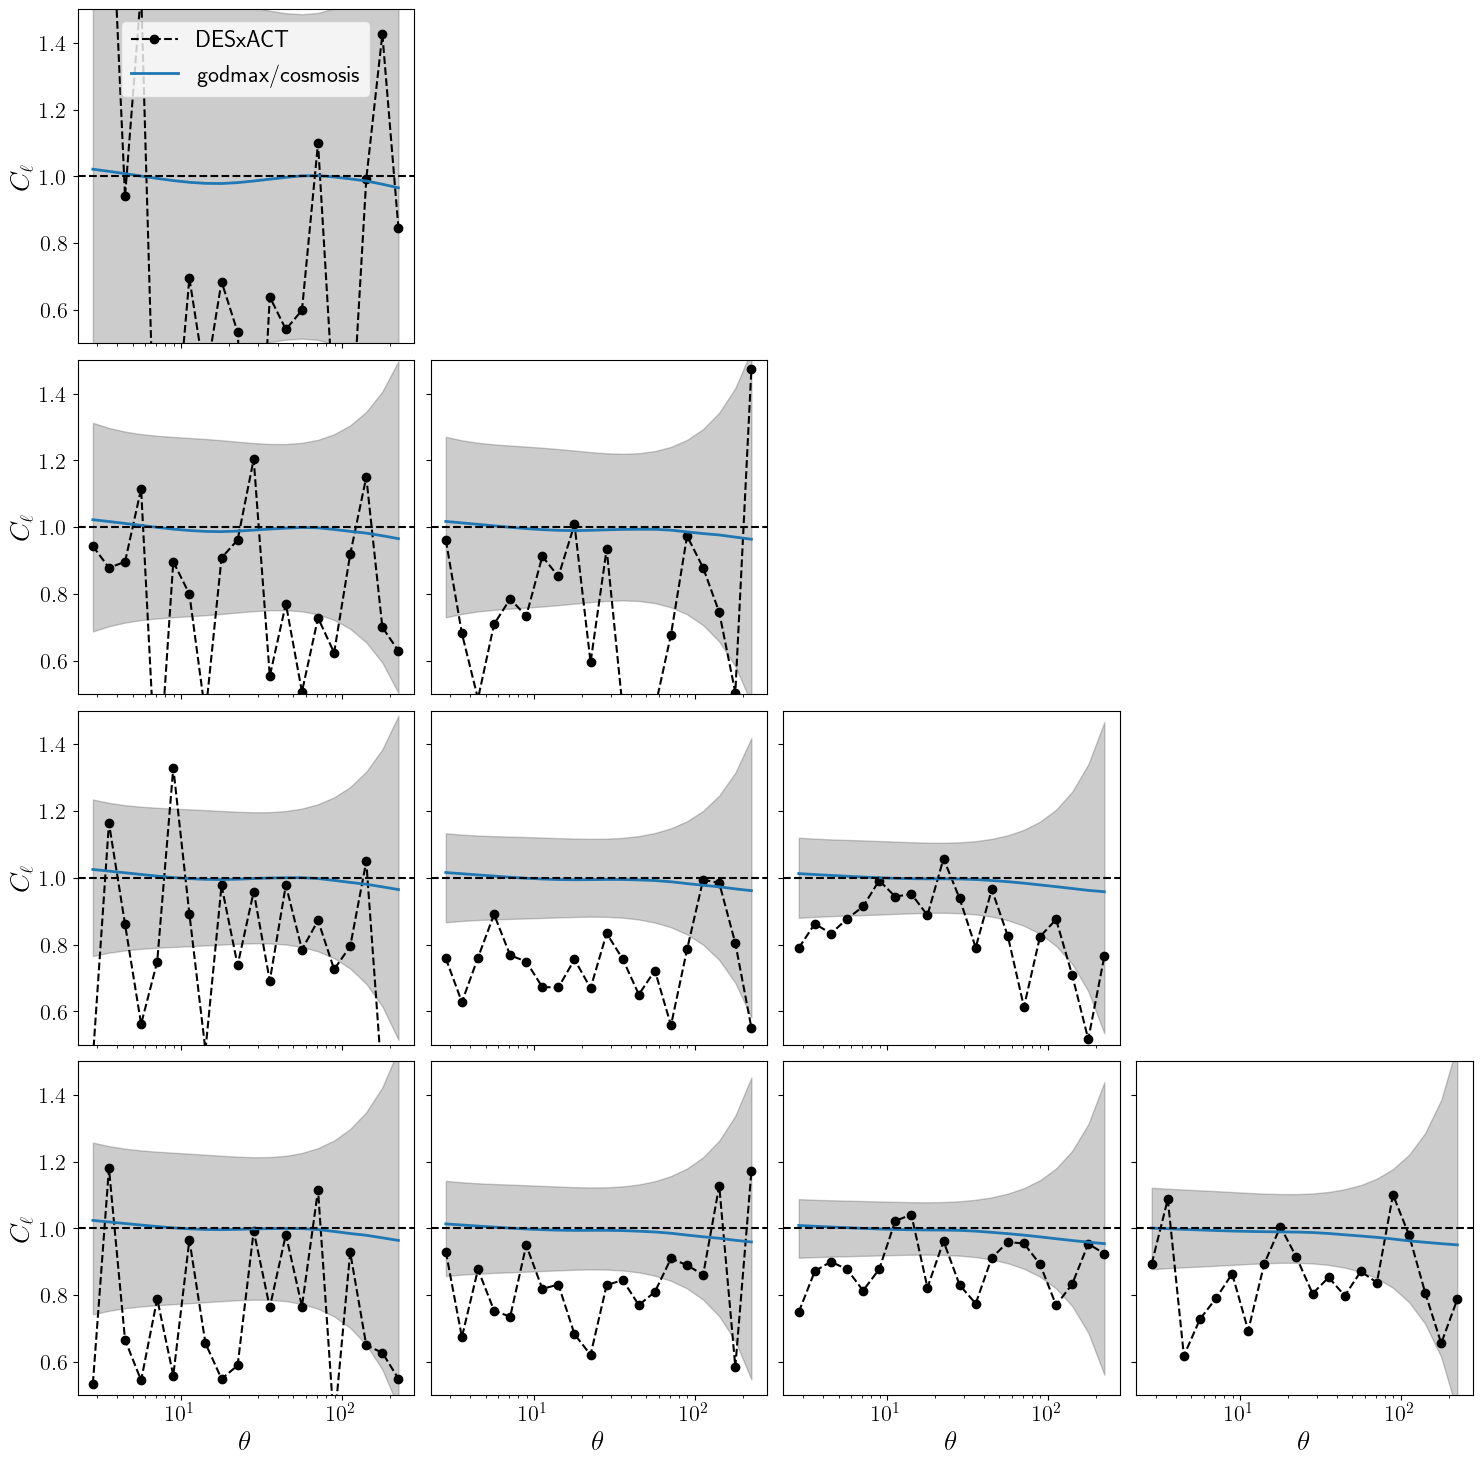

In [55]:
fig, axes = pl.subplots(4, 4, figsize=(18, 18), sharex=True, sharey=True)
# set spacing between suplots:
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji1 in range(4):
    for ji2 in range(4):
        if ji1 <= ji2:
            ax = axes[ji2, ji1]
            # ax.plot(xis_test.angles_data_array, xis_test.xip_out_mat[:,ji2,ji1], label='godmax', lw=2)
            # ax.plot(xis_test.angles_data_array, xis_test.xip_out_mat[:,ji1,ji2], label='godmax', lw=2)            
            # ax.plot(results_fid_cs.block[('shear_xi_plus', 'theta')]*(180*60/np.pi), results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], label='cosmosis', lw=2)
            indsel = np.where((bin1_xip_dv == ji1+1) & (bin2_xip_dv == ji2+1))[0]
            ax.plot(xis_test.angles_data_array, xip_dv[indsel]/results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], marker='o', ls='--', label='DESxACT', color='k')
            ax.plot(xis_test.angles_data_array, xis_test.xip_out_mat[:,ji1,ji2]/results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], label='godmax/cosmosis', lw=2)
            ax.fill_between(xis_test.angles_data_array, 1 - sig_xip_dv[indsel]/results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], 1 + sig_xip_dv[indsel]/results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], alpha=0.2, color='k')
            # ax.plot(results_fid_cs.block[('shear_xi_plus', 'theta')]*(180*60/np.pi), results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], label='cosmosis', lw=2)
            ax.axhline(1.0, ls='--', color='k')

            if ji1 == 0 and ji2 == 0:
                # ax.set_title('xim')
                ax.legend(fontsize=17)
            ax.set_xscale('log')
            # ax.set_yscale('log')
            ax.set_ylim(0.5, 1.5)
            # ax.set_ylim(0, 4e-5)
            # ax.set_xlim(2.5, 250)
            if ji2 == 3:
                ax.set_xlabel(r'$\theta$', fontsize=20)
            if ji1 == 0:
                ax.set_ylabel(r'$C_{\ell}$', fontsize=20)
            ax.tick_params(axis='both', which='major', labelsize=16)
            ax.tick_params(axis='both', which='minor', labelsize=16)

            # if ji < 2:
                # ax.axvspan(0, 10, color='gray', alpha=0.2)
        else:
            # delete the subplot:
            fig.delaxes(axes[ji2, ji1])
    # ax.set_xlim(0, 20)
# fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xip_dv.png', bbox_inches='tight', dpi=300)
pl.show()

 

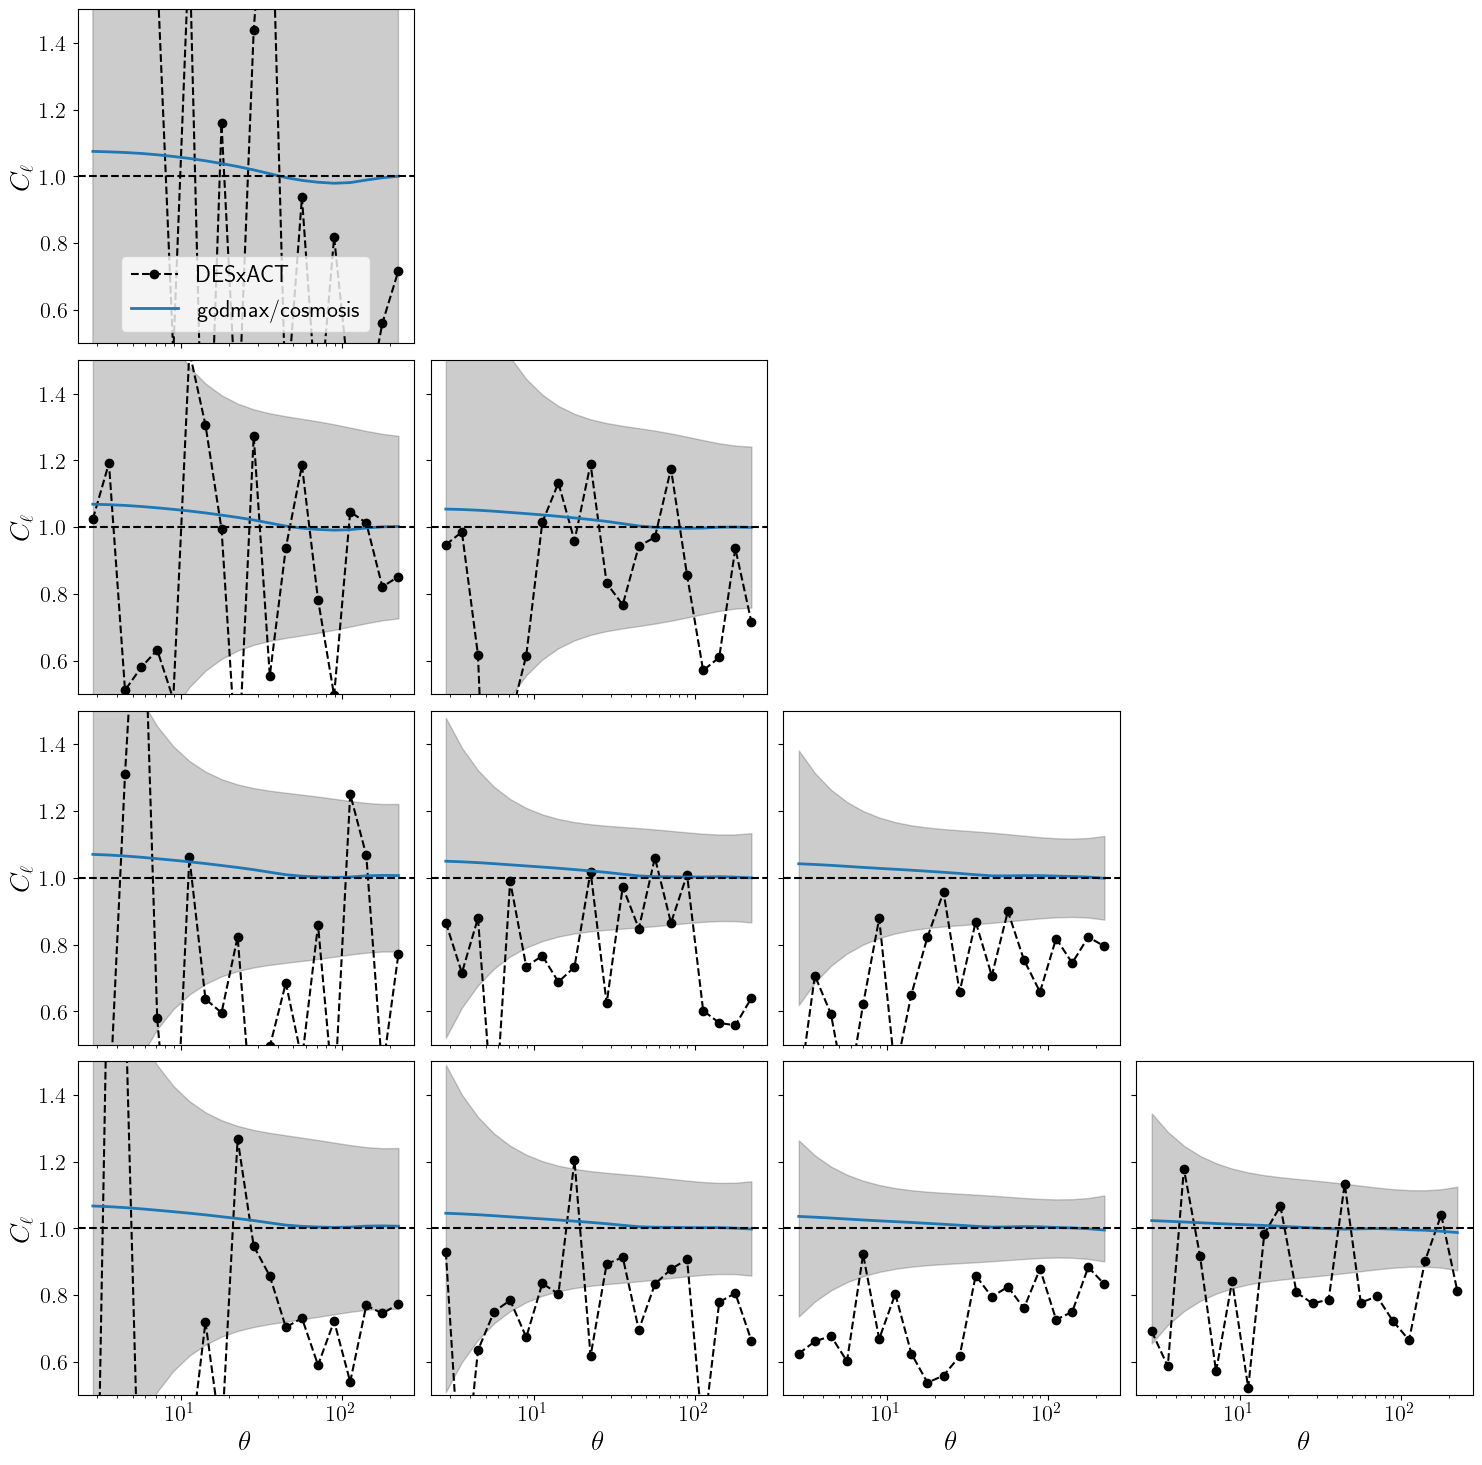

In [56]:
fig, axes = pl.subplots(4, 4, figsize=(18, 18), sharex=True, sharey=True)
# set spacing between suplots:
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji1 in range(4):
    for ji2 in range(4):
        if ji1 <= ji2:
            ax = axes[ji2, ji1]
            # ax.plot(xis_test.angles_data_array, xis_test.xip_out_mat[:,ji2,ji1], label='godmax', lw=2)
            # ax.plot(xis_test.angles_data_array, xis_test.xip_out_mat[:,ji1,ji2], label='godmax', lw=2)            
            # ax.plot(results_fid_cs.block[('shear_xi_plus', 'theta')]*(180*60/np.pi), results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], label='cosmosis', lw=2)
            indsel = np.where((bin1_xip_dv == ji1+1) & (bin2_xip_dv == ji2+1))[0]
            ax.plot(xis_test.angles_data_array, xim_dv[indsel]/results_fid_cs.block[('shear_xi_minus', f'bin_{ji2+1}_{ji1+1}')], marker='o', ls='--', label='DESxACT', color='k')
            ax.plot(xis_test.angles_data_array, xis_test.xim_out_mat[:,ji1,ji2]/results_fid_cs.block[('shear_xi_minus', f'bin_{ji2+1}_{ji1+1}')], label='godmax/cosmosis', lw=2)
            ax.fill_between(xis_test.angles_data_array, 1 - sig_xim_dv[indsel]/results_fid_cs.block[('shear_xi_minus', f'bin_{ji2+1}_{ji1+1}')], 1 + sig_xim_dv[indsel]/results_fid_cs.block[('shear_xi_minus', f'bin_{ji2+1}_{ji1+1}')], alpha=0.2, color='k')
            # ax.plot(results_fid_cs.block[('shear_xi_plus', 'theta')]*(180*60/np.pi), results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], label='cosmosis', lw=2)
            ax.axhline(1.0, ls='--', color='k')

            if ji1 == 0 and ji2 == 0:
                # ax.set_title('xim')
                ax.legend(fontsize=17)
            ax.set_xscale('log')
            # ax.set_yscale('log')
            ax.set_ylim(0.5, 1.5)
            # ax.set_ylim(0, 4e-5)
            # ax.set_xlim(2.5, 250)
            if ji2 == 3:
                ax.set_xlabel(r'$\theta$', fontsize=20)
            if ji1 == 0:
                ax.set_ylabel(r'$C_{\ell}$', fontsize=20)
            ax.tick_params(axis='both', which='major', labelsize=16)
            ax.tick_params(axis='both', which='minor', labelsize=16)

            # if ji < 2:
                # ax.axvspan(0, 10, color='gray', alpha=0.2)
        else:
            # delete the subplot:
            fig.delaxes(axes[ji2, ji1])
    # ax.set_xlim(0, 20)
# fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xip_dv.png', bbox_inches='tight', dpi=300)
pl.show()

 

In [2]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
# platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
# jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')

import matplotlib
# os.chdir('/Users/shivam/Library/CloudStorage/Dropbox/research/GODMAX/notebooks')
import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
%load_ext autoreload
%autoreload 2
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../data/") 
abs_path_src = os.path.abspath(curr_path / "../src/") 
abs_path_results = os.path.abspath(curr_path / "../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

%matplotlib inline
%load_ext autoreload
%autoreload 2




1 1


/projects/bdne/spandey3/envs/godmax/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# !pip install deepmerge


In [27]:
from deepmerge import always_merger
import yaml
abs_path_params = os.path.abspath(curr_path / "../param_files/")

def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
new_data = read_yaml(abs_path_params + '/DESxACT/params_v2.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)

from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 4
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])

analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]

lmin, lmax, dl_log_array = 1.0, 81000.0, 0.23025851/3.
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)
analysis_dict['tSZ_transition_model'] = 'poweradd'
analysis_dict['model_matter'] = 'halofit'


other_params_dict['A_IA'] = 0.1
other_params_dict['eta_IA'] = 0.5
H0 = 69.0
Om = 0.3
Ob = 0.048
sigma8 = 0.8
ns = 0.97

cosmo_params_dict = {'flat': True, 'H0': H0, 'Om0': Om, 'Ob0': Ob, 'sigma8': sigma8, 'ns': ns, 'w0':-1.0}
sim_params_dict['cosmo'] = cosmo_params_dict



In [28]:
from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi

# get_power_test = get_power_BCMP(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
xis_test = get_xi(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)




In [29]:
# /projects/bdne/spandey3/cs_godmax/cosmosis-standard-library/output/sim_y3_shear_codecomp_godmax.fits
from astropy.io import fits
df_cs = fits.open('/projects/bdne/spandey3/cs_godmax/cosmosis-standard-library/output/sim_y3_shear_codecomp_godmax.fits')
# df_cs.info()
xip_dv = df_cs['xip'].data['VALUE']
xim_dv = df_cs['xim'].data['VALUE']
bin1_xip_dv = df_cs['xip'].data['BIN1']
bin2_xip_dv = df_cs['xip'].data['BIN2']
bin1_xim_dv = df_cs['xim'].data['BIN1']
bin2_xim_dv = df_cs['xim'].data['BIN2']

cov_xip = cov_cs[0:200,:][:,0:200]
cov_xim = cov_cs[200:400,:][:,200:400]
sig_xip_dv = np.sqrt(np.diag(cov_xip))
sig_xim_dv = np.sqrt(np.diag(cov_xim))
# print(cov_cs.shape)


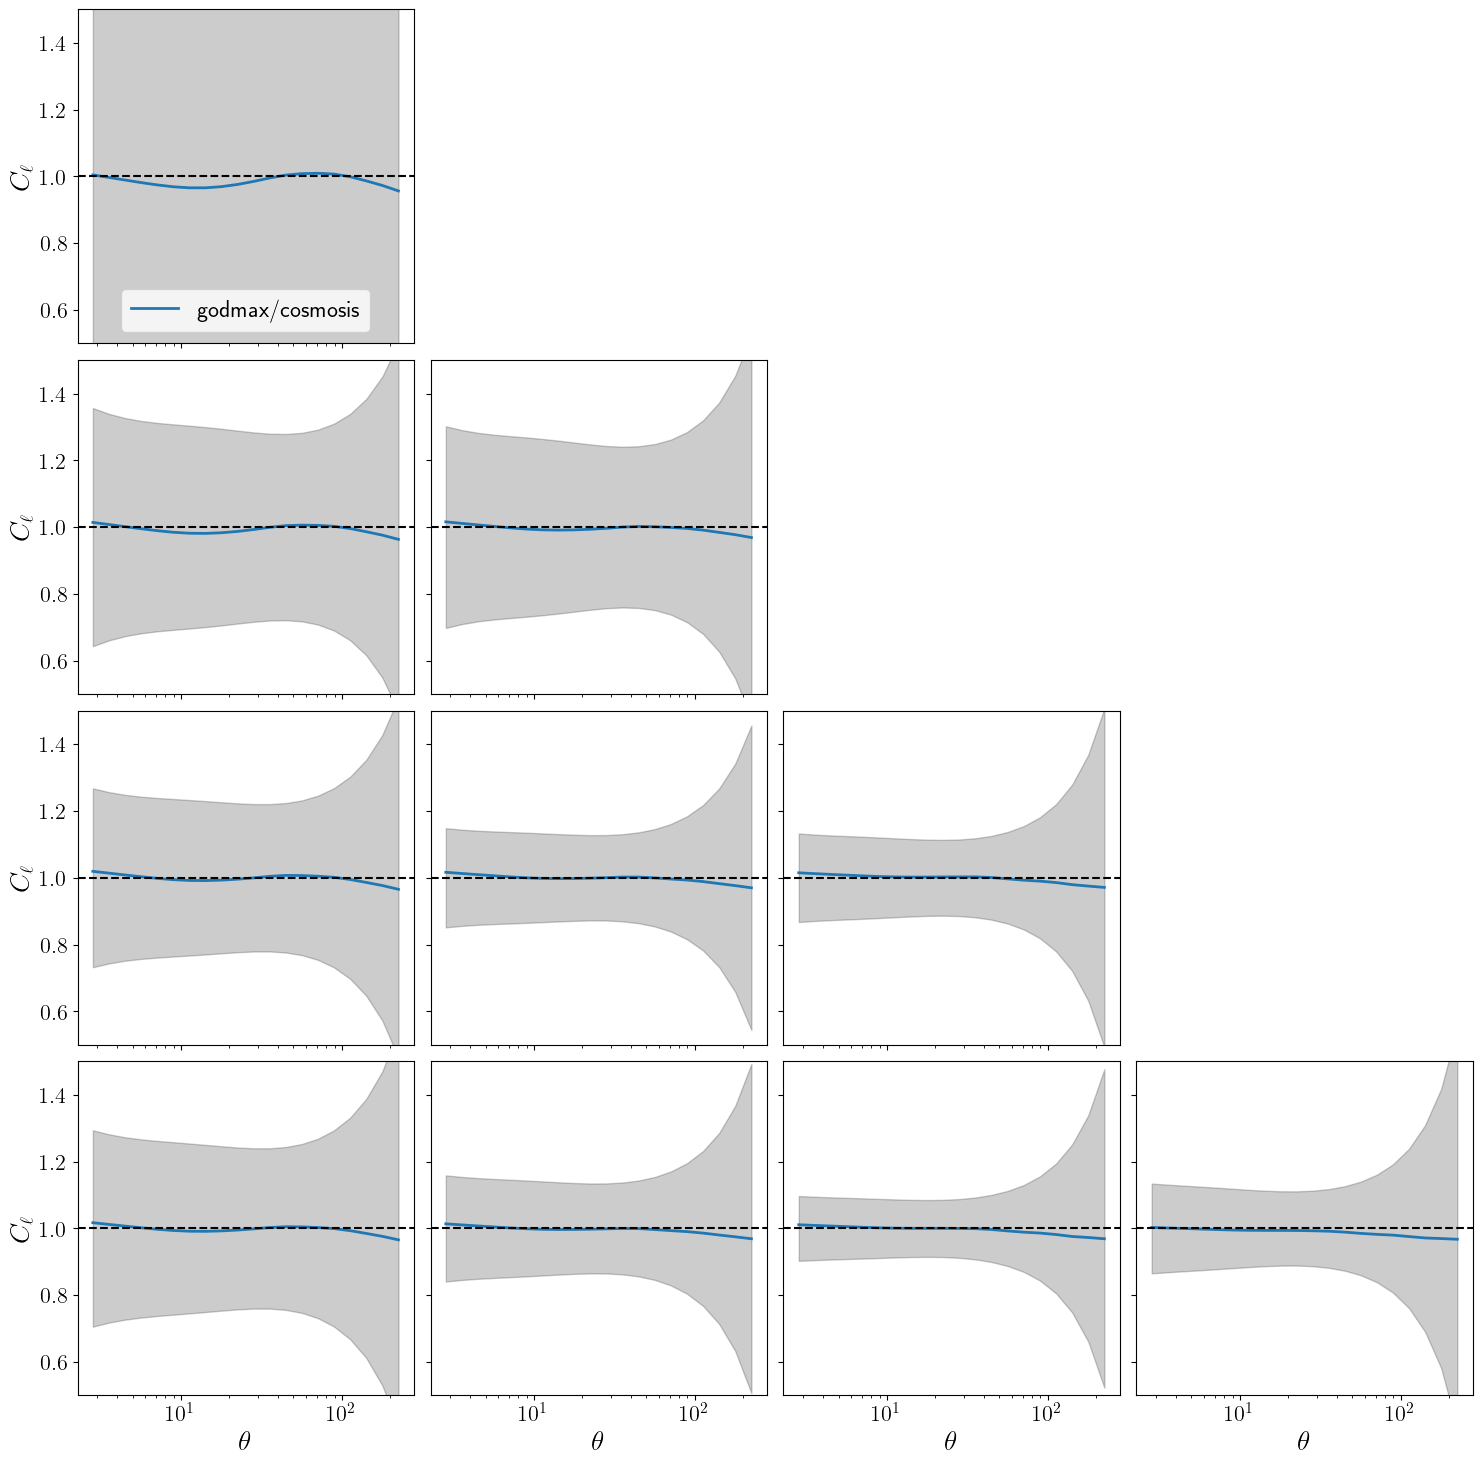

In [30]:
fig, axes = pl.subplots(4, 4, figsize=(18, 18), sharex=True, sharey=True)
# set spacing between suplots:
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji1 in range(4):
    for ji2 in range(4):
        if ji1 <= ji2:
            ax = axes[ji2, ji1]
            indsel = np.where((bin1_xip_dv == ji1+1) & (bin2_xip_dv == ji2+1))[0]
            ax.plot(np.array(xis_test.angles_data_array), np.array(xis_test.xip_out_mat[:,ji1,ji2])/xip_dv[indsel], label='godmax/cosmosis', lw=2)
            ax.fill_between(np.array(xis_test.angles_data_array), 1 - sig_xip_dv[indsel]/xip_dv[indsel], 1 + sig_xip_dv[indsel]/xip_dv[indsel], alpha=0.2, color='k')
            # ax.plot(results_fid_cs.block[('shear_xi_plus', 'theta')]*(180*60/np.pi), results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], label='cosmosis', lw=2)
            ax.axhline(1.0, ls='--', color='k')

            if ji1 == 0 and ji2 == 0:
                # ax.set_title('xim')
                ax.legend(fontsize=17)
            ax.set_xscale('log')
            # ax.set_yscale('log')
            ax.set_ylim(0.5, 1.5)
            # ax.set_ylim(0, 4e-5)
            # ax.set_xlim(2.5, 250)
            if ji2 == 3:
                ax.set_xlabel(r'$\theta$', fontsize=20)
            if ji1 == 0:
                ax.set_ylabel(r'$C_{\ell}$', fontsize=20)
            ax.tick_params(axis='both', which='major', labelsize=16)
            ax.tick_params(axis='both', which='minor', labelsize=16)

            # if ji < 2:
                # ax.axvspan(0, 10, color='gray', alpha=0.2)
        else:
            # delete the subplot:
            fig.delaxes(axes[ji2, ji1])
    # ax.set_xlim(0, 20)
# fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xip_dv.png', bbox_inches='tight', dpi=300)
pl.show()

 

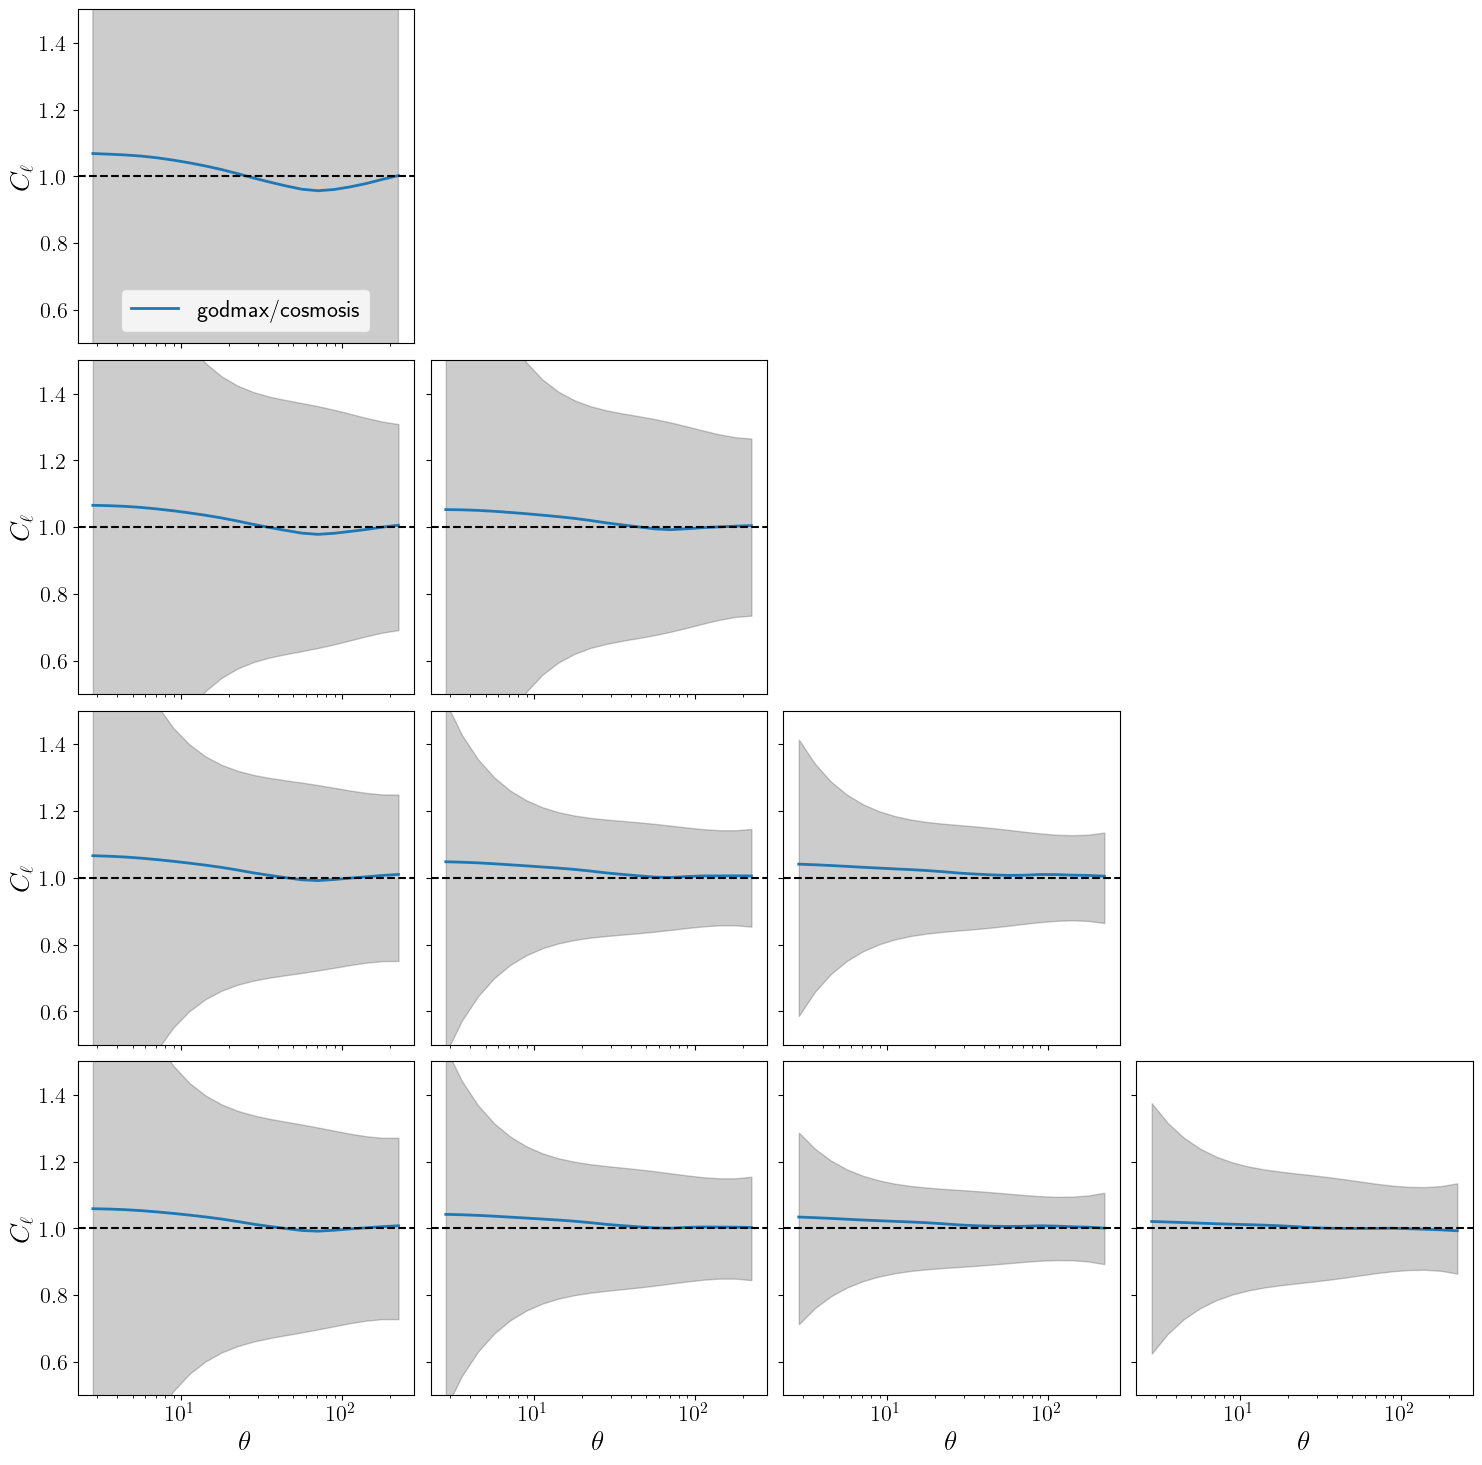

In [31]:
fig, axes = pl.subplots(4, 4, figsize=(18, 18), sharex=True, sharey=True)
# set spacing between suplots:
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji1 in range(4):
    for ji2 in range(4):
        if ji1 <= ji2:
            ax = axes[ji2, ji1]
            indsel = np.where((bin1_xim_dv == ji1+1) & (bin2_xim_dv == ji2+1))[0]
            ax.plot(np.array(xis_test.angles_data_array), np.array(xis_test.xim_out_mat[:,ji1,ji2])/xim_dv[indsel], label='godmax/cosmosis', lw=2)
            ax.fill_between(np.array(xis_test.angles_data_array), 1 - sig_xim_dv[indsel]/xim_dv[indsel], 1 + sig_xim_dv[indsel]/xim_dv[indsel], alpha=0.2, color='k')
            # ax.plot(results_fid_cs.block[('shear_xi_plus', 'theta')]*(180*60/np.pi), results_fid_cs.block[('shear_xi_plus', f'bin_{ji2+1}_{ji1+1}')], label='cosmosis', lw=2)
            ax.axhline(1.0, ls='--', color='k')

            if ji1 == 0 and ji2 == 0:
                # ax.set_title('xim')
                ax.legend(fontsize=17)
            ax.set_xscale('log')
            # ax.set_yscale('log')
            ax.set_ylim(0.5, 1.5)
            # ax.set_ylim(0, 4e-5)
            # ax.set_xlim(2.5, 250)
            if ji2 == 3:
                ax.set_xlabel(r'$\theta$', fontsize=20)
            if ji1 == 0:
                ax.set_ylabel(r'$C_{\ell}$', fontsize=20)
            ax.tick_params(axis='both', which='major', labelsize=16)
            ax.tick_params(axis='both', which='minor', labelsize=16)

            # if ji < 2:
                # ax.axvspan(0, 10, color='gray', alpha=0.2)
        else:
            # delete the subplot:
            fig.delaxes(axes[ji2, ji1])
    # ax.set_xlim(0, 20)
# fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xip_dv.png', bbox_inches='tight', dpi=300)
pl.show()

 